In [13]:
import pandas as pd
from google.colab import drive
drive.mount('/content/drive')

# Ganti 'Data_Nasabah.csv' dengan path yang benar ke file CSV Anda
data = pd.read_csv('/content/drive/My Drive/Learn/Associate Data Scientist/Associate Data Scientist + Python - Nasional/Data_Nasabah.csv', delimiter=';')

# Jumlah data (baris dan kolom)
print("Jumlah data (baris, kolom):", data.shape)

# Informasi tentang tipe data dan skema pengkodean
print("\nInformasi tipe data dan skema pengkodean:")
print(data.info())

# Statistik deskriptif untuk data numerik
print("\nStatistik deskriptif untuk data numerik:")
print(data.describe())

# Melihat beberapa baris pertama data
print("\nBeberapa baris pertama data:")
print(data.head())

# Menampilkan jumlah nilai unik untuk setiap kolom (untuk memahami kategori)
print("\nJumlah nilai unik untuk setiap kolom:")
for column in data.columns:
  print(f"{column}: {data[column].nunique()}")



Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Jumlah data (baris, kolom): (100, 10)

Informasi tipe data dan skema pengkodean:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 10 columns):
 #   Column                     Non-Null Count  Dtype 
---  ------                     --------------  ----- 
 0   nasabah_id                 100 non-null    object
 1   umur                       100 non-null    int64 
 2   jenis_kelamin              100 non-null    object
 3   pendapatan                 100 non-null    int64 
 4   saldo_rata_rata            100 non-null    int64 
 5   jumlah_transaksi           100 non-null    int64 
 6   jenis_produk               100 non-null    object
 7   frekuensi_kunjungi_cabang  100 non-null    int64 
 8   pengguna_mobile_banking    100 non-null    object
 9   skor_kredit                100 non-null    int64 
dtypes: int64(6), object(4

In [14]:
# Melakukan pengkodean pada kolom kategorikal
data['jenis_kelamin'] = data['jenis_kelamin'].map({'Laki-Laki': 1, 'Perempuan': 2})
data['jenis_produk'] = data['jenis_produk'].map({'tabungan': 1, 'kartu_kredit': 2, 'deposito': 3})
data['pengguna_mobile_banking'] = data['pengguna_mobile_banking'].map({'YA': 1, 'TIDAK': 2})
print(data.head()) # Memastikan perubahan

  nasabah_id  umur  jenis_kelamin  pendapatan  saldo_rata_rata  \
0       N001    22              2     5800000          1508000   
1       N002    64              2     5700000          1254000   
2       N003    27              2     2950000           590000   
3       N004    34              2     3100000           186000   
4       N005    45              1     6700000          1474000   

   jumlah_transaksi  jenis_produk  frekuensi_kunjungi_cabang  \
0                19             1                          1   
1                 9             2                          2   
2                12             1                          1   
3                16             3                          5   
4                15             2                          3   

   pengguna_mobile_banking  skor_kredit  
0                        2          900  
1                        2          900  
2                        1          500  
3                        2          700  
4       

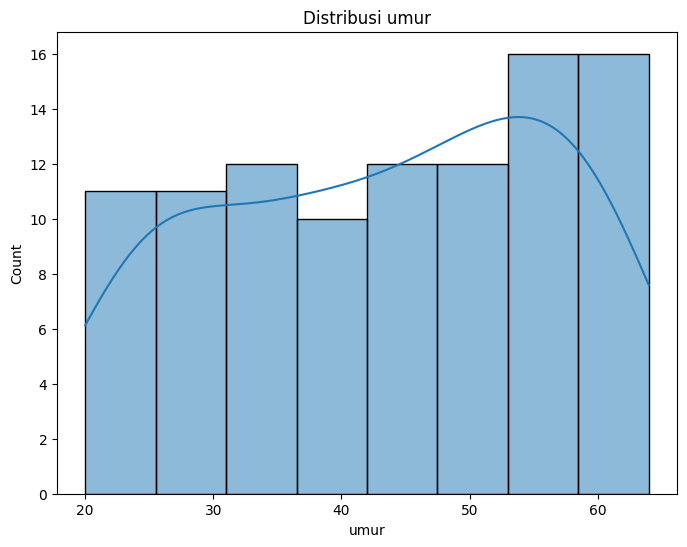

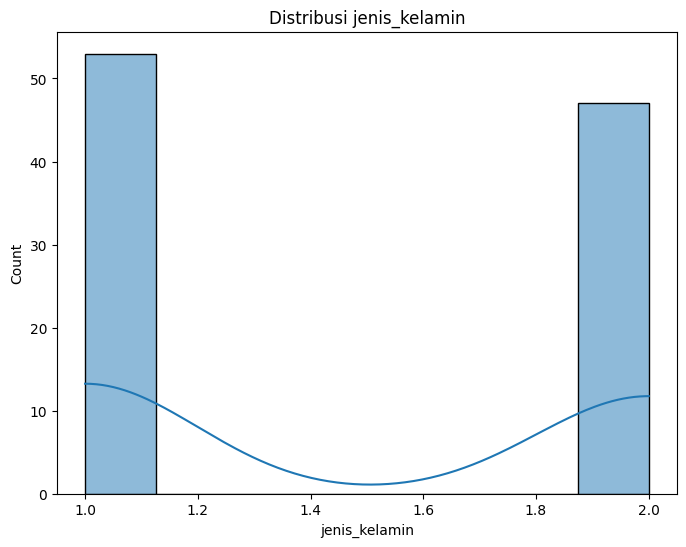

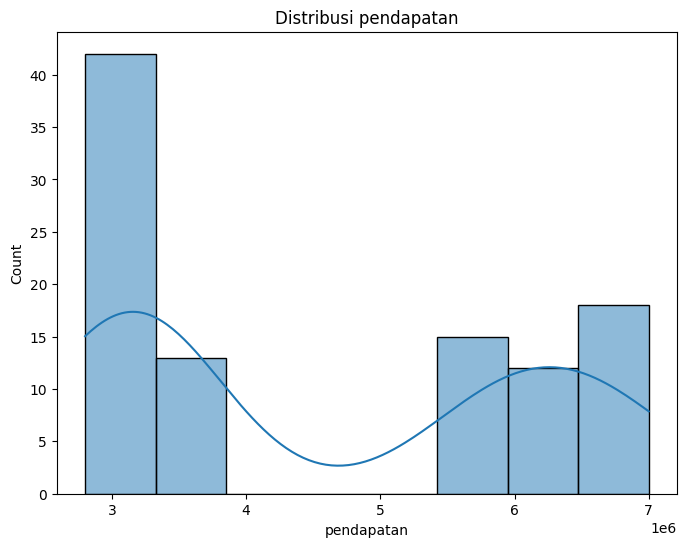

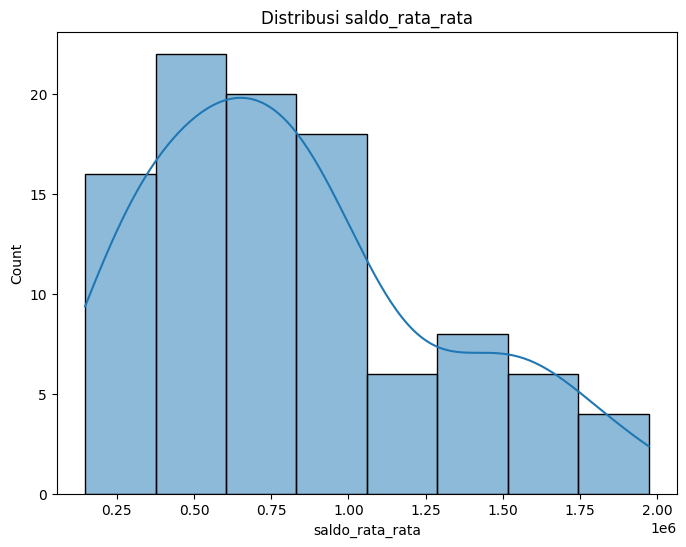

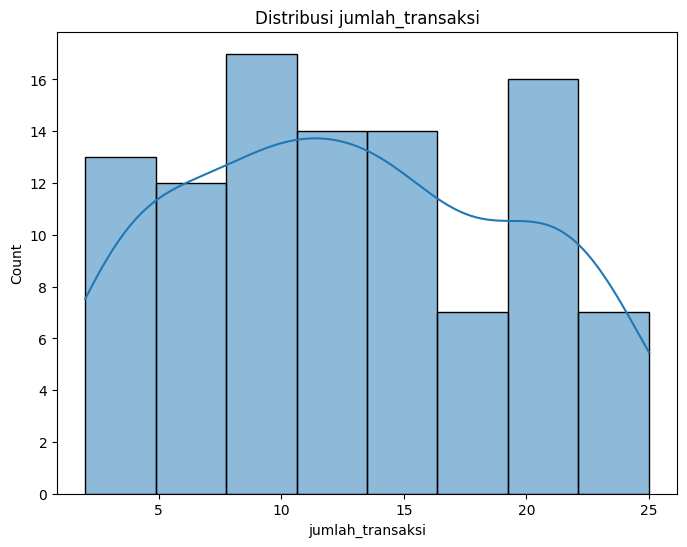

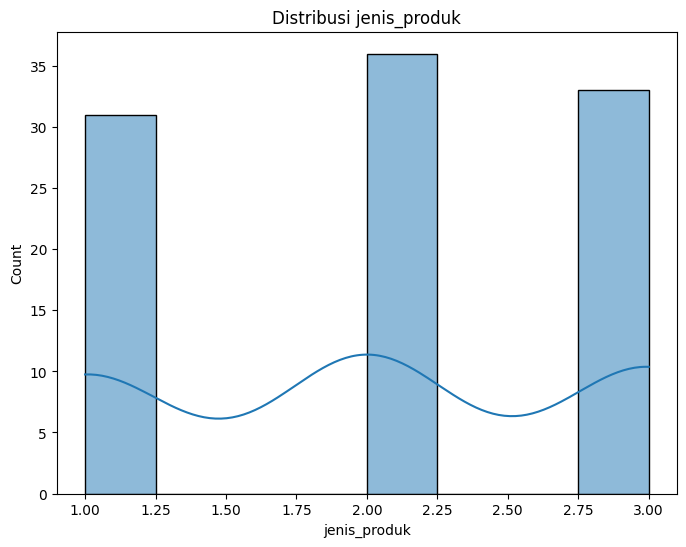

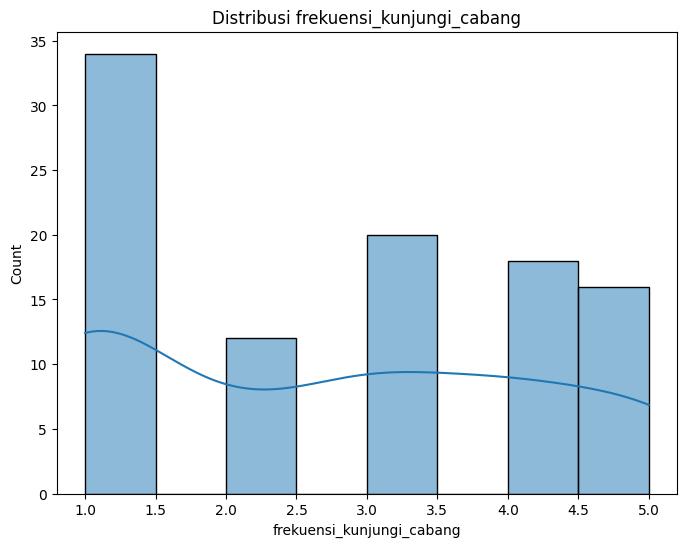

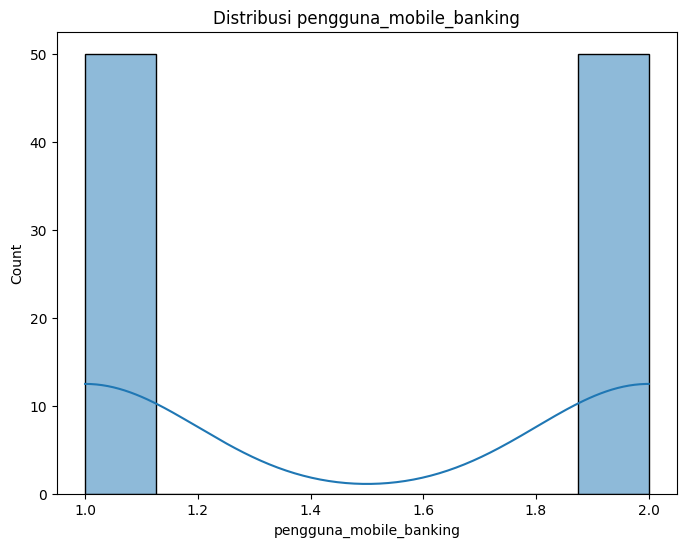

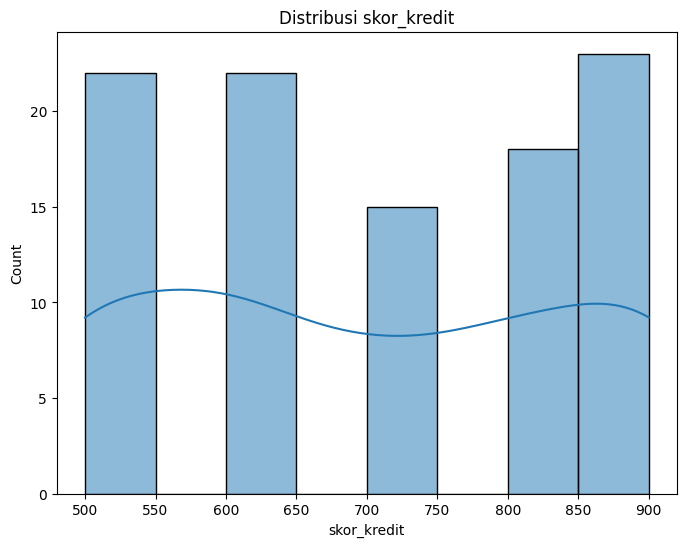

In [18]:
import matplotlib.pyplot as plt
import seaborn as sns

# Analisis Distribusi Data Numerik
numerical_features = data.select_dtypes(include=['number']).columns
for feature in numerical_features:
  plt.figure(figsize=(8, 6))
  sns.histplot(data[feature], kde=True)
  plt.title(f"Distribusi {feature}")
  plt.show()

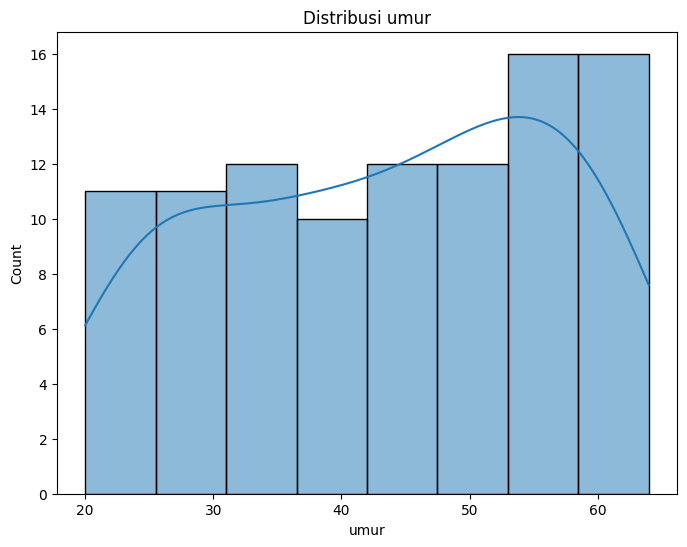

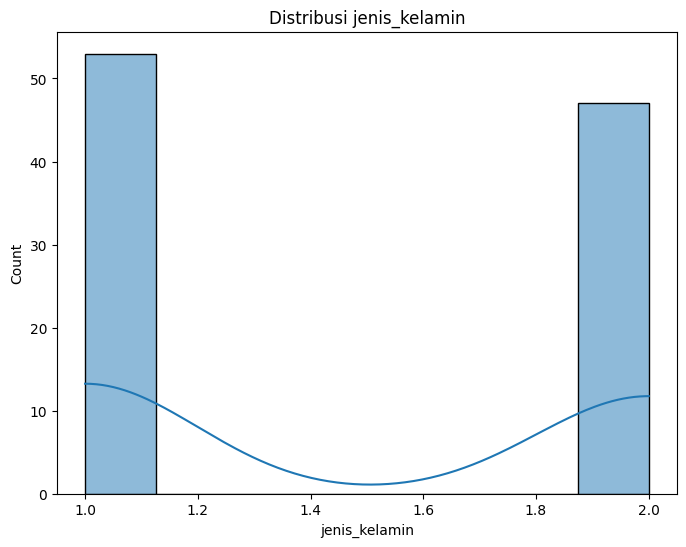

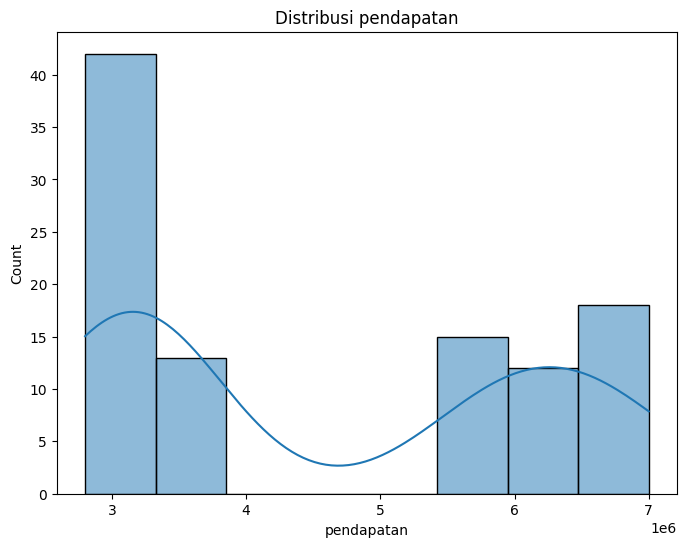

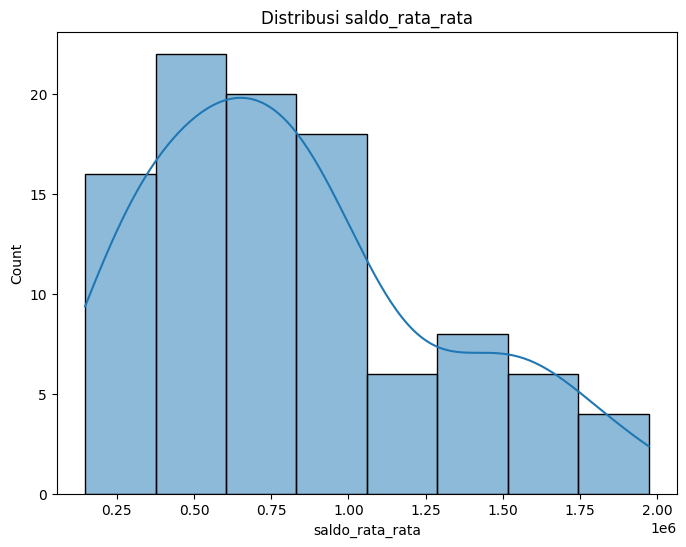

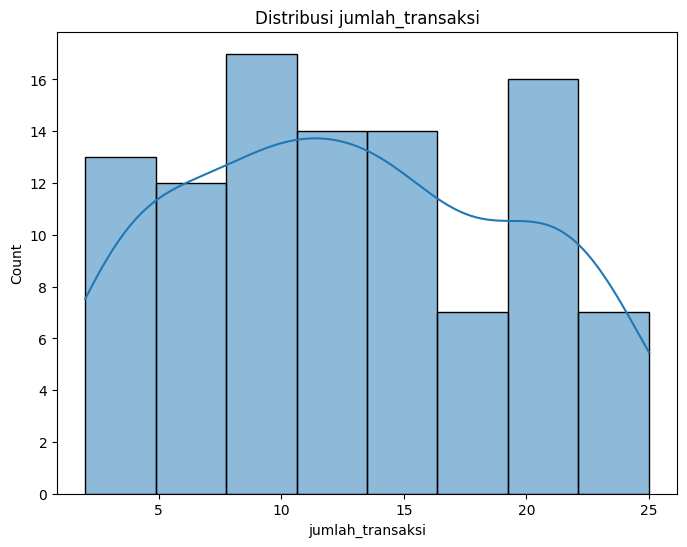

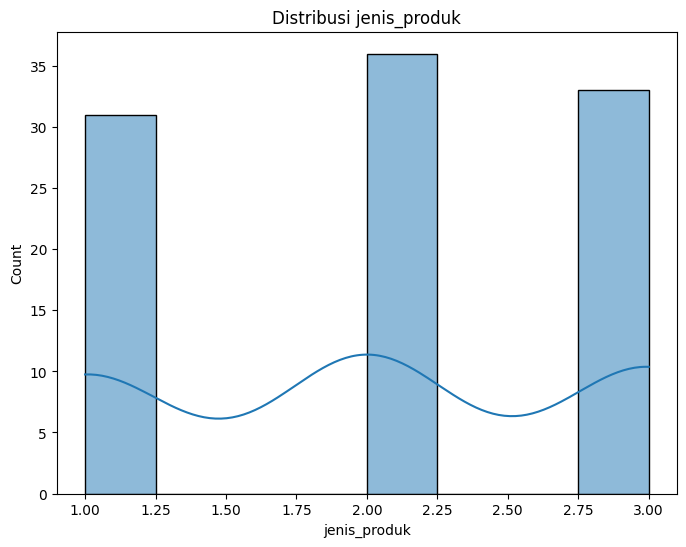

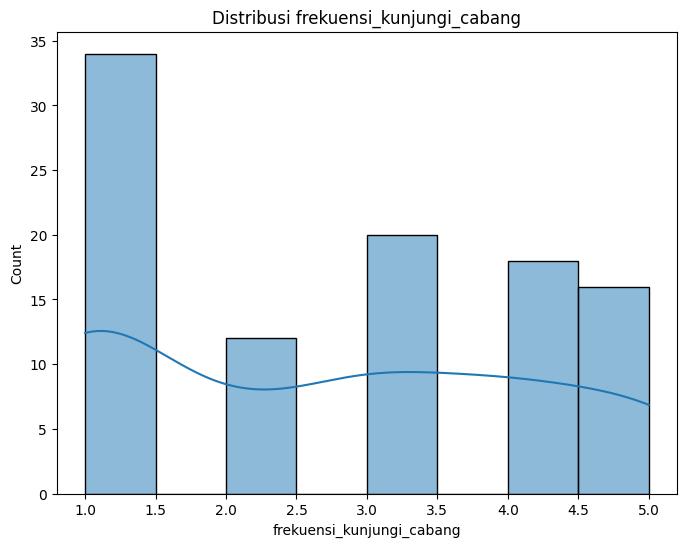

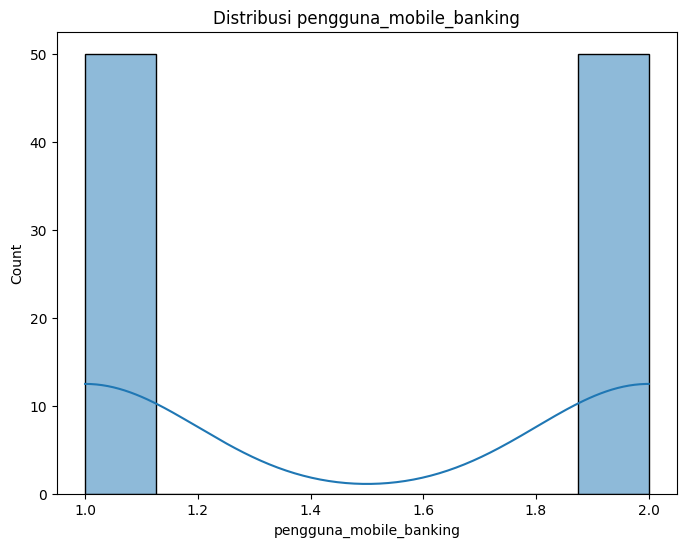

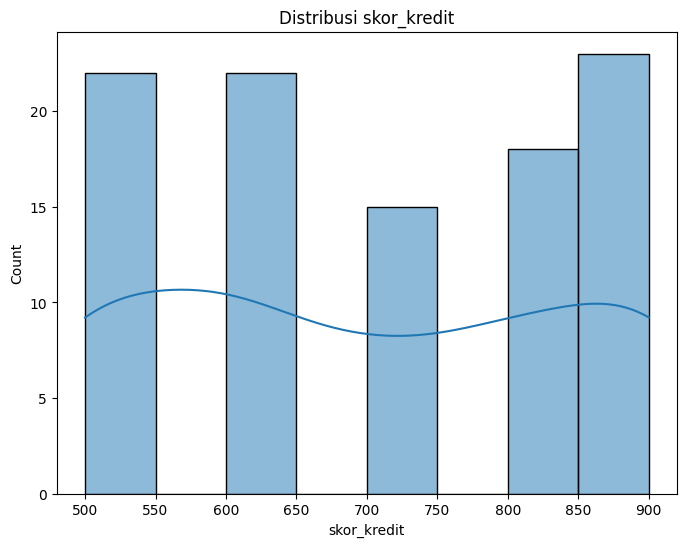

In [20]:
# Analisis Distribusi Data Numerik
numerical_features = data.select_dtypes(include=['number']).columns
for feature in numerical_features:
  plt.figure(figsize=(8, 6))
  sns.histplot(data[feature], kde=True)
  plt.title(f"Distribusi {feature}")
  plt.show()

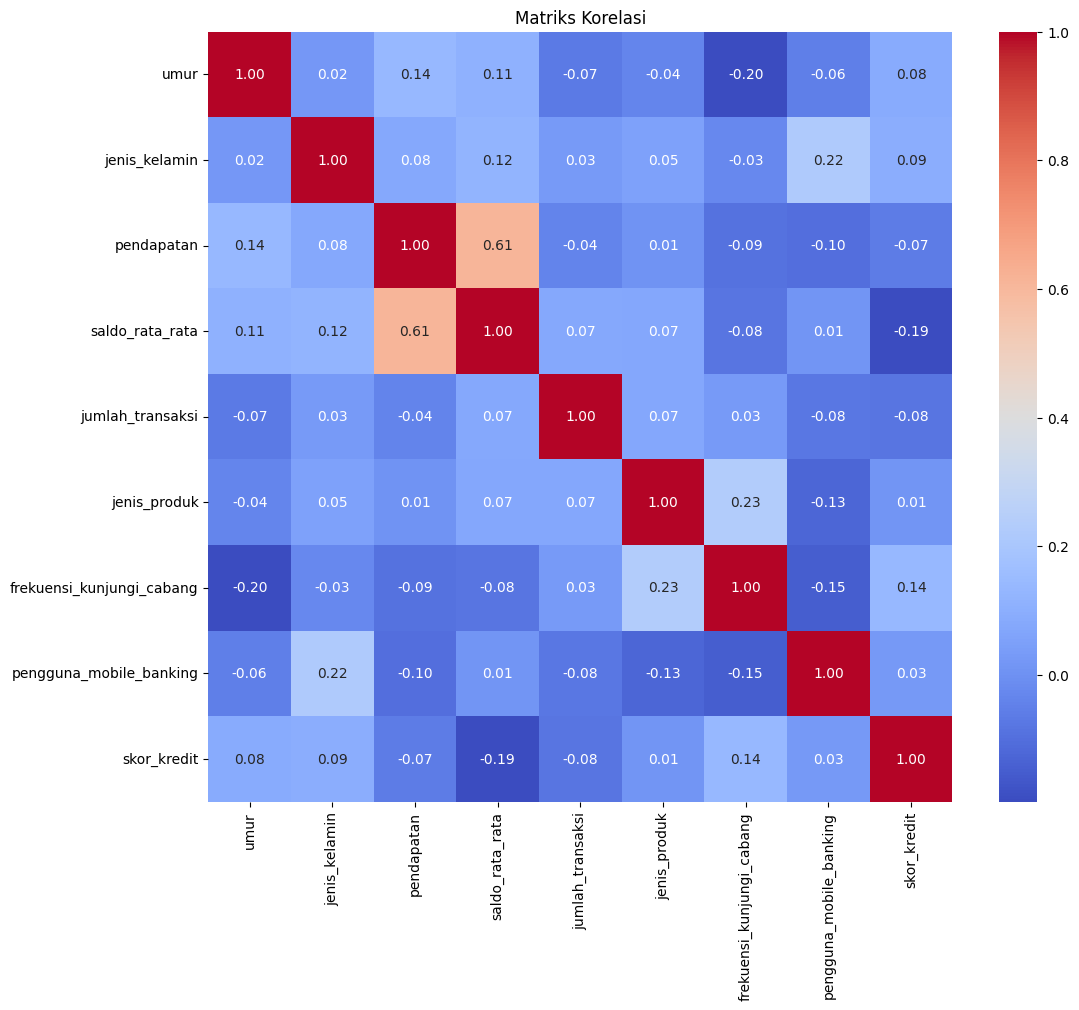

In [21]:
# Analisis Korelasi antar Variabel
numerical_data = data.select_dtypes(include=['number'])
correlation_matrix = numerical_data.corr()  # Calculate correlation on numerical data only
plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Matriks Korelasi")
plt.show()

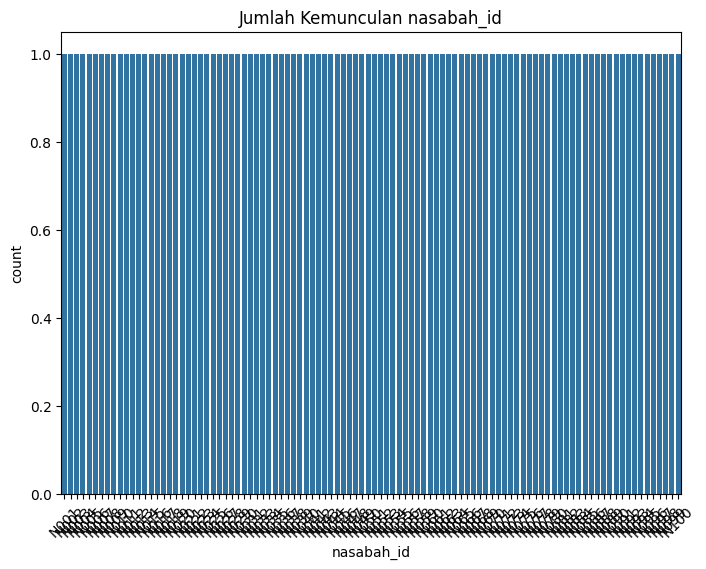

In [22]:
# Analisis Data Kategorikal
categorical_features = data.select_dtypes(include=['object']).columns
for feature in categorical_features:
  plt.figure(figsize=(8, 6))
  sns.countplot(x=feature, data=data)
  plt.title(f"Jumlah Kemunculan {feature}")
  plt.xticks(rotation=45)
  plt.show()


Jumlah Nilai Hilang Setiap Kolom:
nasabah_id                   0
umur                         0
jenis_kelamin                0
pendapatan                   0
saldo_rata_rata              0
jumlah_transaksi             0
jenis_produk                 0
frekuensi_kunjungi_cabang    0
pengguna_mobile_banking      0
skor_kredit                  0
dtype: int64


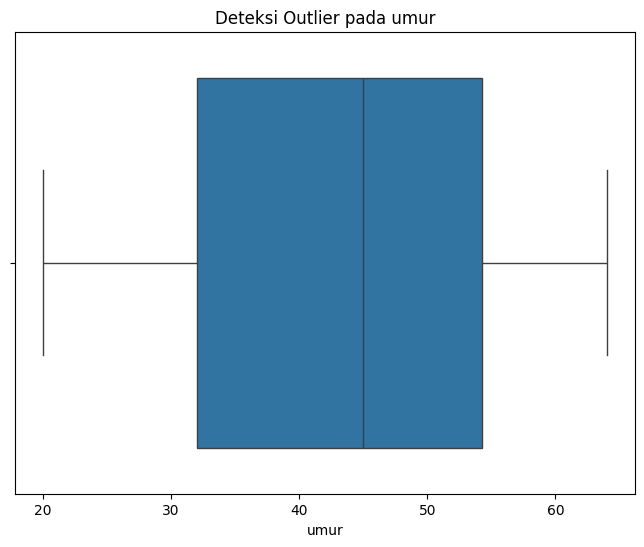

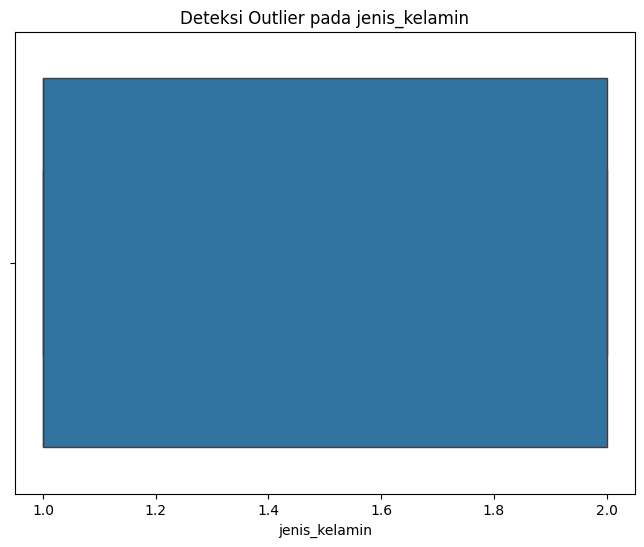

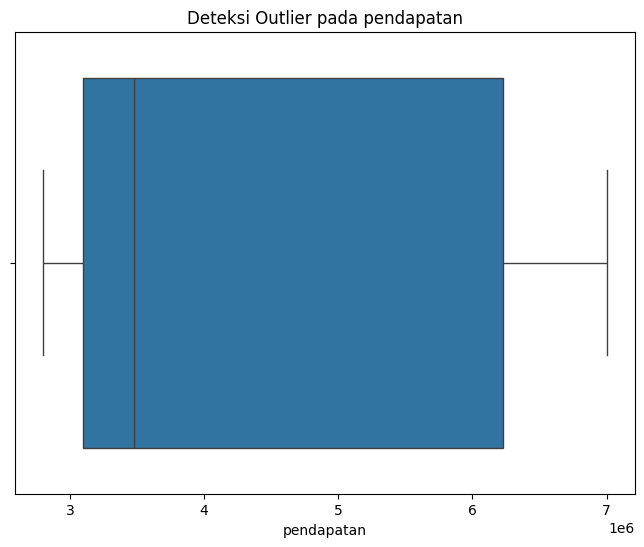

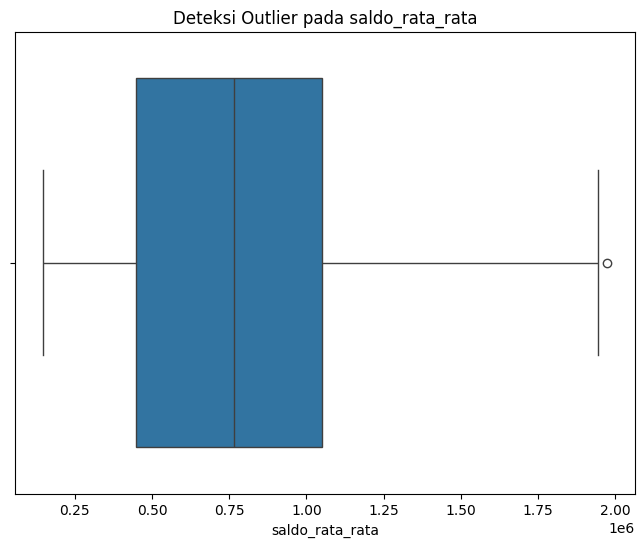

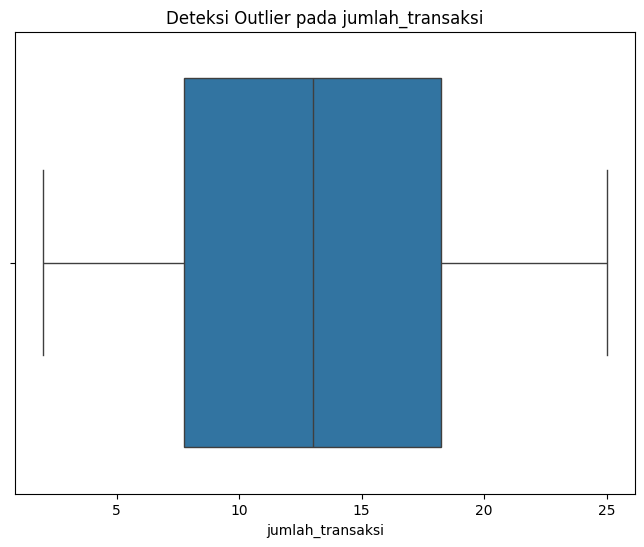

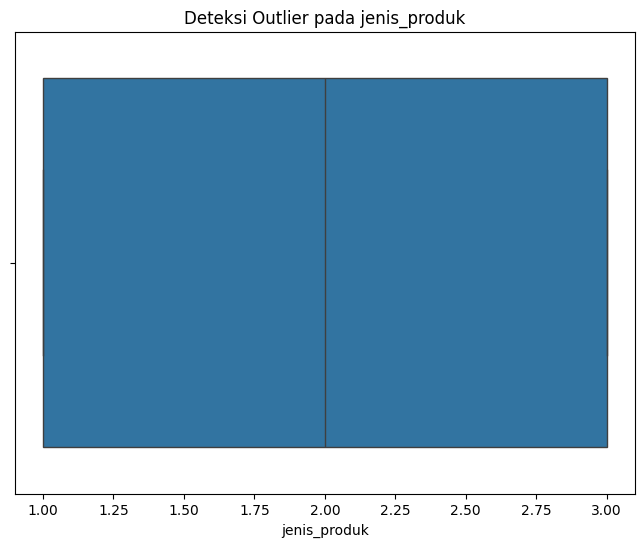

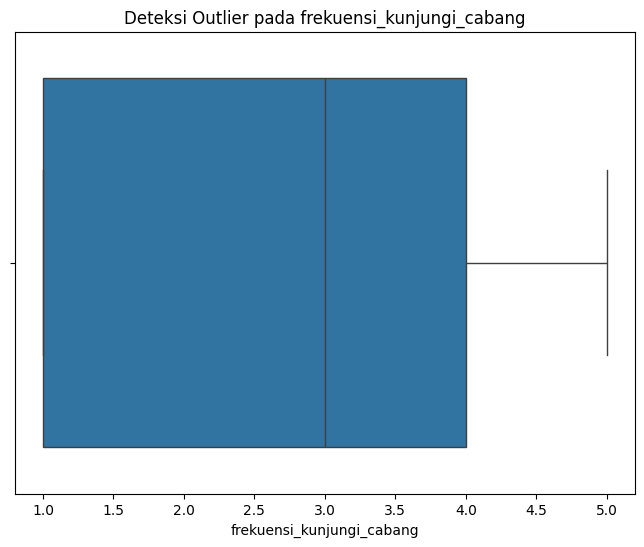

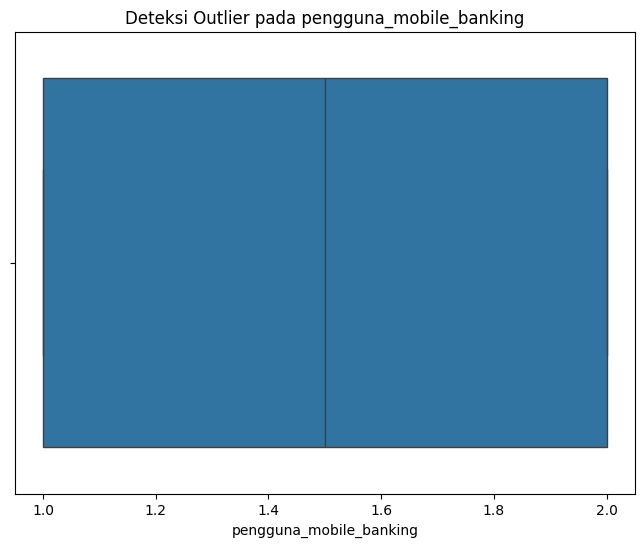

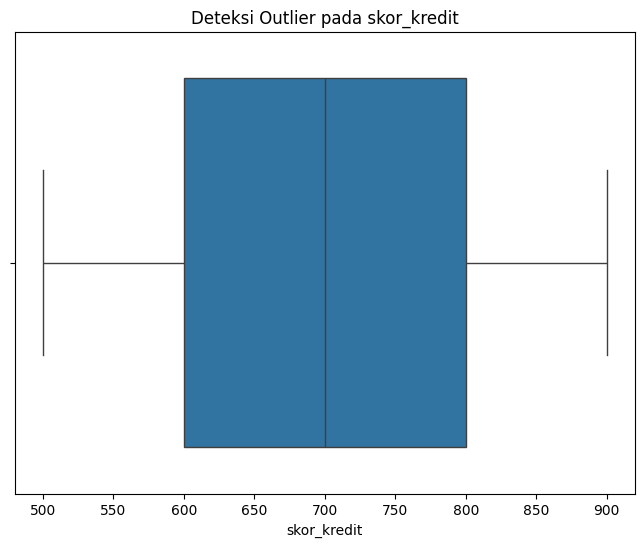

In [23]:
# Analisis Nilai Hilang (Missing Values)
missing_values = data.isnull().sum()
print("\nJumlah Nilai Hilang Setiap Kolom:")
print(missing_values)

# Analisis Outlier (Nilai Aneh)
for feature in numerical_features:
  plt.figure(figsize=(8, 6))
  sns.boxplot(x=data[feature])
  plt.title(f"Deteksi Outlier pada {feature}")
  plt.show()

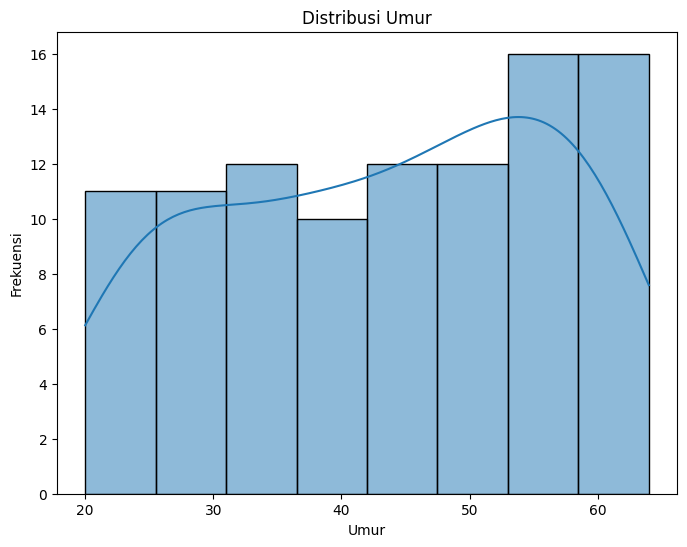

In [24]:
# Menampilkan distribusi data untuk kolom tertentu
# (misalnya, 'Umur')
plt.figure(figsize=(8, 6))
sns.histplot(data['umur'], kde=True)
plt.title('Distribusi Umur')
plt.xlabel('Umur')
plt.ylabel('Frekuensi')
plt.show()

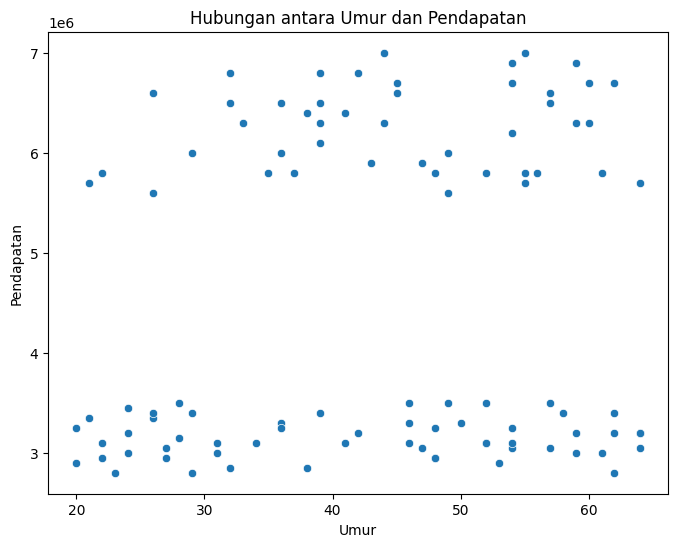

In [25]:
# Analisis hubungan antara dua variabel (misalnya, 'Umur' dan 'Pendapatan')
plt.figure(figsize=(8, 6))
sns.scatterplot(x='umur', y='pendapatan', data=data)
plt.title('Hubungan antara Umur dan Pendapatan')
plt.xlabel('Umur')
plt.ylabel('Pendapatan')
plt.show()

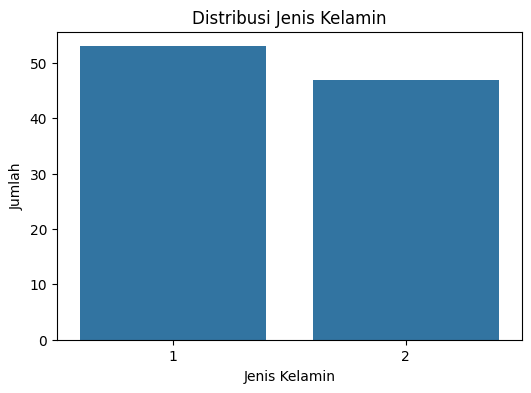

In [26]:
# Menampilkan distribusi data untuk kolom 'Jenis Kelamin'
plt.figure(figsize=(6, 4))
sns.countplot(x='jenis_kelamin', data=data)
plt.title('Distribusi Jenis Kelamin')
plt.xlabel('Jenis Kelamin')
plt.ylabel('Jumlah')
plt.show()

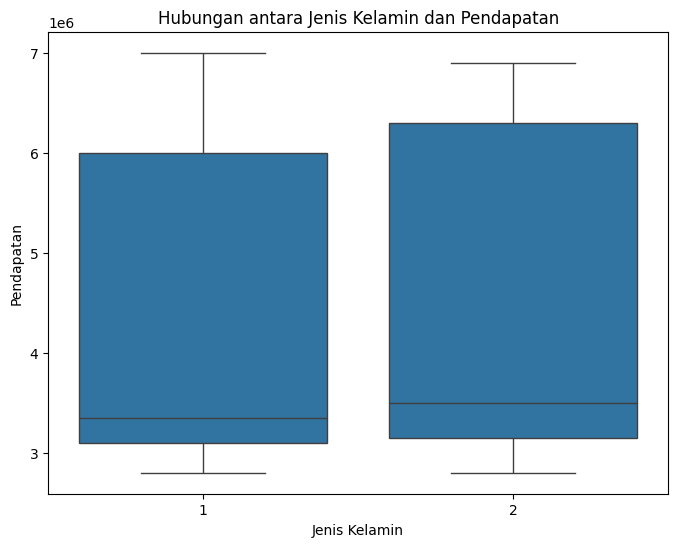

In [27]:
# Menampilkan hubungan antara 'Jenis Kelamin' dan 'Pendapatan'
plt.figure(figsize=(8, 6))
sns.boxplot(x='jenis_kelamin', y='pendapatan', data=data)
plt.title('Hubungan antara Jenis Kelamin dan Pendapatan')
plt.xlabel('Jenis Kelamin')
plt.ylabel('Pendapatan')
plt.show()

In [29]:
# Validasi Data Mendalam dan Detail

# 1. Periksa Konsistensi Data

#   - Periksa apakah nilai dalam kolom tertentu sesuai dengan batasan yang diharapkan.

#   - Contoh: Periksa apakah kolom 'umur' hanya berisi nilai positif.

print("\nValidasi Umur:")
if data['umur'].min() < 0:
    print("Terdapat nilai umur negatif, perlu diperiksa lebih lanjut.")
else:
    print("Nilai umur valid.")


Validasi Umur:
Nilai umur valid.


In [30]:
#   - Periksa apakah kolom 'jenis_kelamin' hanya berisi 'Laki-laki' atau 'Perempuan'.

print("\nValidasi Jenis Kelamin:")
invalid_gender = data['jenis_kelamin'].apply(lambda x: x not in ['Laki-Laki', 'Perempuan']).sum()
if invalid_gender > 0:
    print(f"Terdapat {invalid_gender} nilai jenis kelamin yang tidak valid.")
else:
    print("Nilai jenis kelamin valid.")


Validasi Jenis Kelamin:
Terdapat 100 nilai jenis kelamin yang tidak valid.


In [31]:
# 2. Deteksi dan Tangani Duplikat
#   - Periksa apakah ada baris data yang duplikat dan hapus jika perlu.

duplicate_rows = data.duplicated().sum()
if duplicate_rows > 0:
    print(f"\nTerdapat {duplicate_rows} baris data duplikat.")
    # data = data.drop_duplicates()  # Hapus baris duplikat jika dirasa perlu
else:
    print("\nTidak ada baris data duplikat.")


Tidak ada baris data duplikat.


In [32]:
# 3. Validasi Rentang Data
#   - Periksa apakah nilai dalam kolom tertentu berada dalam rentang yang wajar.
#   - Contoh: Periksa apakah kolom 'saldo_rata_rata' memiliki nilai yang realistis.

print("\nValidasi Saldo Rata-rata:")
if data['saldo_rata_rata'].max() > 1972000: # Ganti dengan batas atas yang sesuai
    print("Terdapat nilai saldo rata-rata yang tidak realistis, perlu diperiksa.")
else:
    print("Nilai saldo rata-rata dalam rentang yang wajar.")


Validasi Saldo Rata-rata:
Nilai saldo rata-rata dalam rentang yang wajar.
